# Scrum velocity vs throughput — architecture tradeoffs (cleaned layout)

Generated: `2026-03-08 01:32:22 +0000`

This notebook regenerates:

1. **Side-by-side quadrant charts** (Scrum velocity vs Throughput) with:
   - red **Debt Path**
   - green **Escape / Investment J-hook**
   - reduced text collisions (labels moved, smaller fonts, callouts in boxes, legend)

2. **Time chart** with **smoothstep blending** (no kink/bump).


In [194]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from enum import StrEnum, IntEnum
from dataclasses import dataclass
from typing import Any

class HexColor(IntEnum):
  BLUE_LIGHT = 0xB2CAD4
  BLUE_BRIGHT = 0X78E2F0
  BLUE = 0X1A245D
  BLUE_MEDIUM = 0x141C48
  BLUE_DARK = 0x12183F
  BLUE_DEEP = 0x0A122A
  BLUE_DEEPER = 0x060B15
  BLUE_STEEL = 0x698894
  BLUE_NAVY = 0x264653
  TEAL = 0x62C9C9
  TEAL_LIGHT = 0x73EBEB
  TEAL_DARK = 0x204141
  TEAL_DEEP = 0x0D3D3D
  TEAL_MEDIUM = 0x346A6A
  TEAL_MEDIUM_PLUS = 0x306363
  GREEN_LIGHT = 0x33BC3C
  GREEN= 0x4DAA2A
  GREEN_MEDIUM = 0x4CAF50
  GREEN_MEDIUM2 = 0x2A9A31
  GREEN_DARK  = 0x388E3C
  GREEN_DARKER  = 0x17561B
  GREEN_DARKER_ALT = 0x195E1E
  GREEN_DEEP = 0x0E3411
  GREEN_DEEPER  = 0x081C09
  ORANGE = 0xFF9800
  COPPER_LIGHT = 0xE89048
  COPPER_ORANGE = 0xF4A261
  COPPER_RED = 0xE76F51
  COPPER_DARK = 0x6A3210
  BRONZE_DEEP = 0x504D47
  BRONZE_DARK = 0x5A3A12
  BRONZE_LIGHT = 0xE0B060
  BRONZE_GOLD = 0xE9C46A
  YELLOW = 0xFFEB3B
  PARCHMENT_LIGHT = 0xFCF5E5
  PARCHMENT = 0xF4EDDE
  PARCHMENT_MEDIUM = 0xD2CCBF
  PARCHMENT_DARK = 0xB0ABA0
  PARCHMENT_DEEP = 0x8E8A81
  PURPLE_LIGHT = 0x8A4A9A
  PURPLE = 0x7B2D8E
  PURPLE_MEDIUM = 0x572064
  PURPLE_DARK = 0x501D5B
  PURPLE_DARKER = 0x43184D
  PURPLE_DEEP = 0x321239
  PURPLE_DEEPER = 0x2A0A3A
  RED_LIGHT = 0xF44336
  RED = 0xC1121F
  RED_MEDIUM  = 0xB71C1C
  RED_DARK = 0x981515
  RED_DARKER = 0x6F0F0F
  RED_DEEP = 0x4D0B0B
  RED_DEEPER = 0x3A0808

ALL_COLOR_STR = json.dumps(COLORS, indent=2)

def get_color(color:HexColor, prefix:str|None='#') -> str:
  colorstring:str = hex(color.value)
  return colorstring.replace("0x", prefix) if prefix else colorstring



MEDIUM_RED:str = get_color(HexColor.RED_MEDIUM)
MEDIUM_RED

'#b71c1c'

In [195]:
def smoothstep(t: np.ndarray) -> np.ndarray:
    """Classic smoothstep: 0..1 -> 0..1 with smooth derivatives at ends."""
    t = np.clip(t, 0.0, 1.0)
    return t * t * (3.0 - 2.0 * t)


def bezier_curve(P0, P1, P2, P3, n: int = 200) -> np.ndarray:
    """Return cubic Bezier curve points."""
    t = np.linspace(0.0, 1.0, n)[:, None]
    P0 = np.array(P0, dtype=float)
    P1 = np.array(P1, dtype=float)
    P2 = np.array(P2, dtype=float)
    P3 = np.array(P3, dtype=float)
    return (1 - t) ** 3 * P0 + 3 * (1 - t) ** 2 * t * P1 + 3 * (1 - t) * t ** 2 * P2 + t ** 3 * P3


## 1) Side-by-side quadrant charts (cleaner annotation placement)

['font.cursive', 'font.family', 'font.fantasy', 'font.monospace', 'font.sans-serif', 'font.serif', 'font.size', 'font.stretch', 'font.style', 'font.variant', 'font.weight', 'legend.fontsize', 'legend.title_fontsize', 'mathtext.fontset', 'pdf.fonttype', 'pdf.use14corefonts', 'pgf.rcfonts', 'ps.fonttype', 'svg.fonttype']


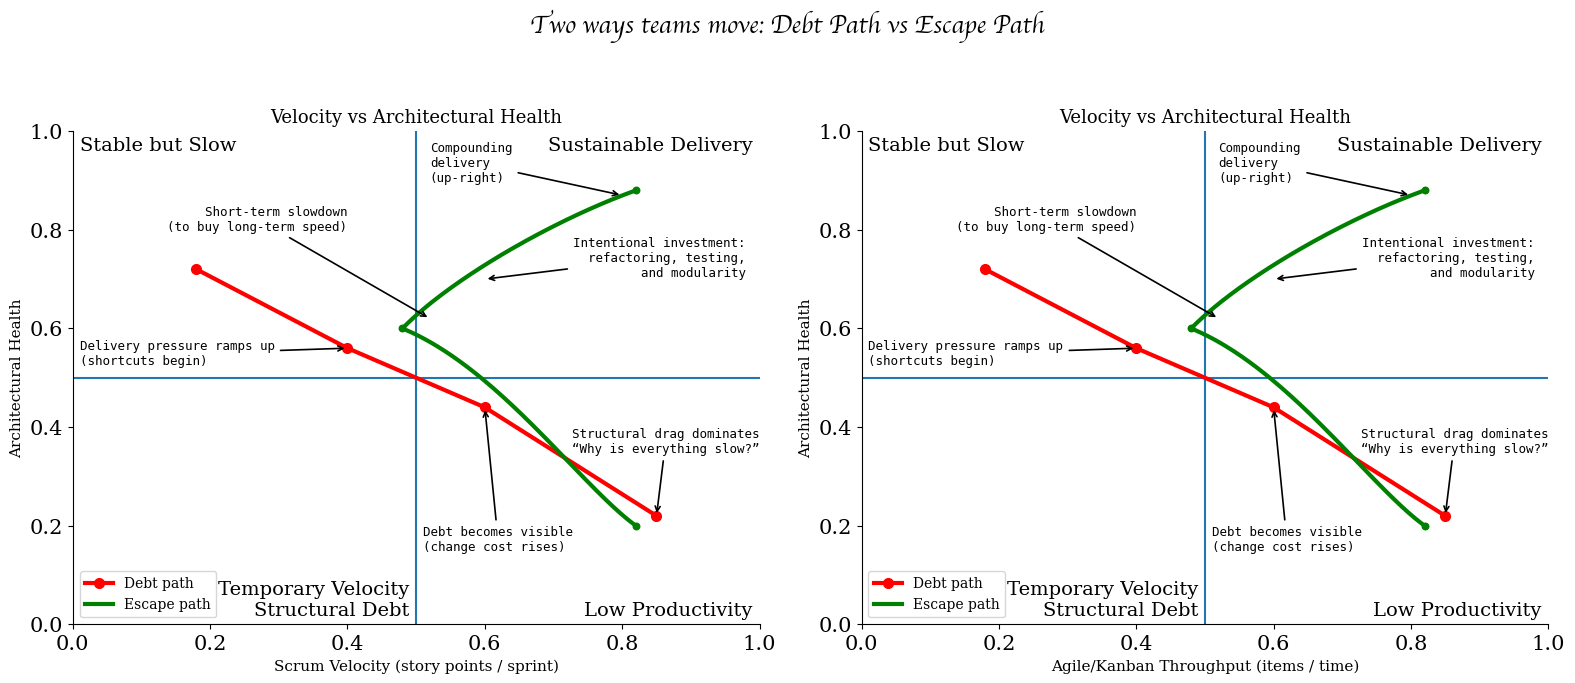

PosixPath('output/scrum-velocity-health.png')

In [196]:
ff:str = "Monospace"
def draw_quadrant(ax: plt.Axes, x_label: str) -> None:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title("Velocity vs Architectural Health", fontsize=13)
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel("Architectural Health", fontsize=11)
    ax.fontfamily=ff

    # Quadrant lines
    ax.axvline(0.5, linewidth=1.5)
    ax.axhline(0.5, linewidth=1.5)

    # Quadrant labels (smaller + anchored away from center)
    ax.text(0.01, 0.99, "Stable but Slow", fontsize=14, va="top",  ha="left")
    ax.text(0.99, 0.99, "Sustainable Delivery", fontsize=14, va="top",  ha="right")
    ax.text(0.99, 0.01, "Low Productivity", fontsize=14, va="bottom", ha="right")
    ax.text(0.49, 0.01, "Temporary Velocity\nStructural Debt", fontsize=14, va="bottom", ha="right")

    # Paths
    red_pts = np.array([
        [0.18, 0.72],
        [0.40, 0.56],
        [0.60, 0.44],
        [0.85, 0.22],
    ])
    ax.plot(red_pts[:, 0], red_pts[:, 1], "-o", lw=3, ms=7, color="red", label="Debt path"
    )

    # Green J-hook (two Bezier segments)
    segA = bezier_curve((0.82, 0.20), (0.74, 0.28), (0.62, 0.52), (0.48, 0.60), n=140)
    segB = bezier_curve((0.48, 0.60), (0.55, 0.70), (0.70, 0.82), (0.82, 0.88), n=140)
    green = np.vstack([segA, segB])
    ax.plot(green[:, 0], green[:, 1], linewidth=3, color="green", label="Escape path")
    ax.scatter([0.82, 0.48, 0.82], [0.20, 0.60, 0.88], s=22, color="green", zorder=3)

    # Legend instead of center text
    ax.legend(loc="lower left", frameon=True, fontsize=10)

    # Callouts in semi-opaque boxes to reduce collisions
    box = dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.8)
    
    annotate_font:str='Monospace'

    ax.annotate(
        "Delivery pressure ramps up\n(shortcuts begin)",
        xy=red_pts[1],
        xytext=(0.01, 0.52),
        arrowprops=dict(arrowstyle="->", lw=1.2),
        ha='left',
        va='bottom',
        fontsize=9,
        fontfamily=annotate_font,
        bbox=box,
    )

    ax.annotate(
        "Debt becomes visible\n(change cost rises)",
        xy=red_pts[2],
        xytext=(0.51, 0.2),
        arrowprops=dict(arrowstyle="->", lw=1.2),
        ha="left",
        va="top",
        fontfamily=annotate_font,
        fontsize=9,
        bbox=box,
    )

    ax.annotate(
        "Structural drag dominates\n“Why is everything slow?”",
        xy=red_pts[3],
        xytext=(1.0, 0.40),
        ha='right',
        va='top',
        fontfamily=annotate_font,
        arrowprops=dict(arrowstyle="->", lw=1.2),
        fontsize=9,
        bbox=box,
    )

    ax.annotate(
        "Short-term slowdown\n(to buy long-term speed)",
        xy=(0.52, 0.62),
        xytext=(0.4, 0.85),
        ha='right',
        va='top',
        arrowprops=dict(arrowstyle="->", lw=1.2),
        fontsize=9,
        fontfamily=annotate_font,
        bbox=box
    )

    ax.annotate(
        "Intentional investment:\nrefactoring, testing,\nand modularity",
        xy=(0.60, 0.70),
        xytext=(0.98, 0.70),
        backgroundcolor="#000000FF",
        ha='right',
        va='bottom',
        arrowprops=dict(arrowstyle="->", lw=1.2),
        fontsize=9,
        bbox=box,
        fontfamily='Monospace',
    )

    ax.annotate(
        "Compounding\ndelivery\n(up-right)",
        xy=(0.80, 0.87),
        xytext=(0.52, 0.98),
        ha="left",
        va="top",
        arrowprops=dict(arrowstyle="->", lw=1.2),
        fontsize=9,
        bbox=box,
        fontfamily='Monospace',
    )


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
keys  = list(plt.rcParams.keys())
print(f"{[k for k in keys if 'font' in k]}")


plt.rcParams["font.family"] = ["serif"]
plt.rcParams["font.size"] = 15.0
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


draw_quadrant(axes[0], "Scrum Velocity (story points / sprint)")
draw_quadrant(axes[1], "Agile/Kanban Throughput (items / time)")
fig.suptitle("Two ways teams move: Debt Path vs Escape Path", fontsize=18, fontfamily='cursive', fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])


out1 = Path("./output/scrum-velocity-health.png")
fig.savefig(out1, dpi=200, bbox_inches="tight")
plt.show()

out1


## 2) Time chart (smoothstep blend, no kink)

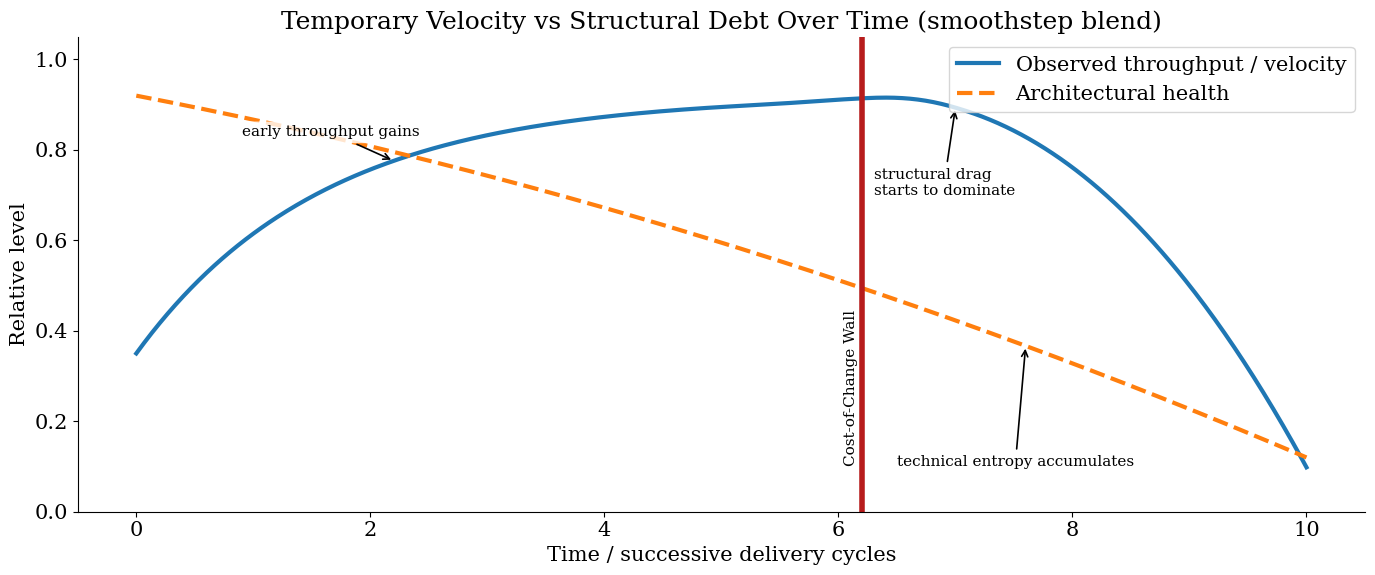

PosixPath('output/temporary_velocity_vs_structural_debt_smoothed_clean.png')

In [197]:
fig = plt.figure(figsize=(14, 6))
ax = plt.gca()



x = np.linspace(0, 10, 600)

# Early gains: rising saturating curve
g = 0.35 + (0.92 - 0.35) * (1 - np.exp(-x / 1.6))

# Late drag: decline after wall
peak = 0.92
x0 = 6.2
L = 4.0
p = 2.2
d = peak * np.maximum(0.0, 1.0 - ((np.maximum(0.0, x - x0) / L) ** p))

# Smooth transition weight around x0 with width k
k = 1.8
w = smoothstep((x - (x0 - k / 2)) / k)

# Observed throughput/velocity is a smooth blend
y_obs = (1 - w) * g + w * d

# Architectural health: smooth gradual decline
health = 0.92 - 0.05 * x - 0.003 * (x ** 2)
health = np.clip(health, 0.0, 1.0)

ax.plot(x, y_obs, linewidth=3, label="Observed throughput / velocity")
ax.plot(x, health, linewidth=3, linestyle="--", label="Architectural health")

# Vertical marker ("cost-of-change wall")
ax.axvline(x0, linestyle="-", linewidth=4, color=MEDIUM_RED)
ax.text(x0 - 0.15, 0.10, "Cost-of-Change Wall", rotation=90, va="bottom", fontsize=11)

# Text boxes (semi-opaque) reduce overlap
box = dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.8)

ax.annotate(
    "early throughput gains",
    xy=(2.2, float(np.interp(2.2, x, y_obs))),
    xytext=(0.9, 0.83),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=11,
    bbox=box,
)

ax.annotate(
    "structural drag\nstarts to dominate",
    xy=(7.0, float(np.interp(7.0, x, y_obs))),
    xytext=(6.3, 0.7),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=11,
    bbox=box,
)

ax.annotate(
    "technical entropy accumulates",
    xy=(7.6, float(np.interp(7.6, x, health))),
    xytext=(6.5, 0.10),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=11,
    bbox=box,
)

ax.set_title("Temporary Velocity vs Structural Debt Over Time (smoothstep blend)")
ax.set_xlabel("Time / successive delivery cycles")
ax.set_ylabel("Relative level")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right")

fig.tight_layout()

out2 = Path("./output/temporary_velocity_vs_structural_debt_smoothed_clean.png")
fig.savefig(out2, dpi=200, bbox_inches="tight")
plt.show()

out2


###### 